SUPPLEMENTARY ANALYSIS

In [30]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

# Initialise Spark session
spark = (
    SparkSession.builder
    .appName("BNPL_Project")
    .master("local[2]")
    .config("spark.driver.memory", "2g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

# Reduce unnecessary Spark logs
spark.sparkContext.setLogLevel("WARN")

# Verify Spark is running
print("Spark is working!")
print("Spark version:", spark.version)

# Test Spark
spark.range(5).show()

26/10/11 04:26:49 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


Spark is working!
Spark version: 4.0.4
+---+
| id|
+---+
|  0|
|  1|
|  2|
|  3|
|  4|
+---+



In [2]:
# load data

ranked = pd.read_parquet(
    "../data/curated/final_ranking.parquet"
)

excluded = pd.read_csv(
    "../data/curated/excluded_merchants.csv",
    dtype={"merchant_abn": str}
)

top100 = pd.read_csv(
    "../data/curated/final_top100.csv",
    dtype={"merchant_abn": str}
)

top10_by_segment = pd.read_csv(
    "../data/curated/final_top10_by_segment.csv",
    dtype={"merchant_abn": str}
)

enriched = spark.read.parquet(
    "../data/curated/final_external_enriched"
)

print("ranked:", len(ranked))
print("excluded:", len(excluded))
print("top100:", len(top100))
print("top10 by segment:", len(top10_by_segment))
print("enriched rows:", enriched.count())

ranked: 566
excluded: 2692
top100: 100
top10 by segment: 50


enriched rows: 71816


In [3]:
# building a consumer-month transacation base in order to analyse interest rate affects on consumption behaviour
tx_full = spark.read.parquet(
    "../data/curated/transactions_with_is_fraud_full"
)

print("FULL TRANSACTION ROWS:", tx_full.count())

tx_full.select(
    F.min("order_datetime").alias("min_date"),
    F.max("order_datetime").alias("max_date")
).show()


tx = (
    tx_full
    .select(
        "user_id",
        "merchant_abn",
        "order_id",
        "order_datetime",
        "dollar_value"
    )
    .withColumn(
        "month",
        F.date_trunc("month", F.col("order_datetime"))
    )
)


consumer_month = (
    tx
    .groupBy("user_id", "month")
    .agg(
        F.countDistinct("order_id").alias("num_transactions"),
        F.sum("dollar_value").alias("monthly_spend"),
        F.avg("dollar_value").alias("avg_transaction_value"),
        F.countDistinct("merchant_abn").alias("num_merchants")
    )
    .orderBy("user_id", "month")
)


print("CONSUMER-MONTH ROWS:", consumer_month.count())

consumer_month.select(
    F.min("month").alias("min_month"),
    F.max("month").alias("max_month")
).show()

consumer_month.show(10, truncate=False)

FULL TRANSACTION ROWS: 14195717


+----------+----------+
|  min_date|  max_date|
+----------+----------+
|2021-02-28|2022-10-26|
+----------+----------+



CONSUMER-MONTH ROWS: 493879


+-------------------+-------------------+
|          min_month|          max_month|
+-------------------+-------------------+
|2021-02-01 00:00:00|2022-10-01 00:00:00|
+-------------------+-------------------+



+-------+-------------------+----------------+------------------+---------------------+-------------+
|user_id|month              |num_transactions|monthly_spend     |avg_transaction_value|num_merchants|
+-------+-------------------+----------------+------------------+---------------------+-------------+
|1      |2021-02-01 00:00:00|2               |163.66824253314365|81.83412126657183    |2            |
|1      |2021-03-01 00:00:00|24              |4420.012164654567 |184.1671735272736    |22           |
|1      |2021-04-01 00:00:00|24              |5708.689518111883 |237.86206325466182   |23           |
|1      |2021-05-01 00:00:00|34              |6432.797619793104 |189.19992999391482   |31           |
|1      |2021-06-01 00:00:00|25              |2107.059899313129 |84.28239597252515    |25           |
|1      |2021-07-01 00:00:00|22              |3185.9823840487543|144.8173810931252    |21           |
|1      |2021-08-01 00:00:00|35              |5175.702099675317 |147.8772028478662

In [4]:
# RBA cash rate -- monthly in order to create a calendar 

rba_rates = [
    # 2021
    ("2021-02-01", 0.10),
    ("2021-03-01", 0.10),
    ("2021-04-01", 0.10),
    ("2021-05-01", 0.10),
    ("2021-06-01", 0.10),
    ("2021-07-01", 0.10),
    ("2021-08-01", 0.10),
    ("2021-09-01", 0.10),
    ("2021-10-01", 0.10),
    ("2021-11-01", 0.10),
    ("2021-12-01", 0.10),

    # 2022
    ("2022-01-01", 0.10),
    ("2022-02-01", 0.10),
    ("2022-03-01", 0.10),
    ("2022-04-01", 0.10),
    ("2022-05-01", 0.35),
    ("2022-06-01", 0.85),
    ("2022-07-01", 1.35),
    ("2022-08-01", 1.85),
    ("2022-09-01", 2.35),
    ("2022-10-01", 2.60),
]

rba_monthly = spark.createDataFrame(
    rba_rates,
    ["month_string", "cash_rate"]
).withColumn(
    "month",
    F.to_timestamp("month_string")
).drop("month_string")

rba_monthly.orderBy("month").show(30, truncate=False)

+---------+-------------------+
|cash_rate|month              |
+---------+-------------------+
|0.1      |2021-02-01 00:00:00|
|0.1      |2021-03-01 00:00:00|
|0.1      |2021-04-01 00:00:00|
|0.1      |2021-05-01 00:00:00|
|0.1      |2021-06-01 00:00:00|
|0.1      |2021-07-01 00:00:00|
|0.1      |2021-08-01 00:00:00|
|0.1      |2021-09-01 00:00:00|
|0.1      |2021-10-01 00:00:00|
|0.1      |2021-11-01 00:00:00|
|0.1      |2021-12-01 00:00:00|
|0.1      |2022-01-01 00:00:00|
|0.1      |2022-02-01 00:00:00|
|0.1      |2022-03-01 00:00:00|
|0.1      |2022-04-01 00:00:00|
|0.35     |2022-05-01 00:00:00|
|0.85     |2022-06-01 00:00:00|
|1.35     |2022-07-01 00:00:00|
|1.85     |2022-08-01 00:00:00|
|2.35     |2022-09-01 00:00:00|
|2.6      |2022-10-01 00:00:00|
+---------+-------------------+



In [5]:
# joining both cash rate and consumption data 
consumer_month_rba = (
    consumer_month
    .join(
        rba_monthly,
        on="month",
        how="left"
    )
    .withColumn(
        "post_rate_hike",
        (F.col("month") >= F.lit("2022-05-01").cast("timestamp")).cast("int")
    )
)

print("ROWS AFTER JOIN:", consumer_month_rba.count())

print(
    "ROWS MISSING CASH RATE:",
    consumer_month_rba.filter(F.col("cash_rate").isNull()).count()
)

consumer_month_rba.select(
    "month",
    "cash_rate",
    "post_rate_hike"
).distinct().orderBy("month").show(30)

ROWS AFTER JOIN: 493879


ROWS MISSING CASH RATE: 0


+-------------------+---------+--------------+
|              month|cash_rate|post_rate_hike|
+-------------------+---------+--------------+
|2021-02-01 00:00:00|      0.1|             0|
|2021-03-01 00:00:00|      0.1|             0|
|2021-04-01 00:00:00|      0.1|             0|
|2021-05-01 00:00:00|      0.1|             0|
|2021-06-01 00:00:00|      0.1|             0|
|2021-07-01 00:00:00|      0.1|             0|
|2021-08-01 00:00:00|      0.1|             0|
|2021-09-01 00:00:00|      0.1|             0|
|2021-10-01 00:00:00|      0.1|             0|
|2021-11-01 00:00:00|      0.1|             0|
|2021-12-01 00:00:00|      0.1|             0|
|2022-01-01 00:00:00|      0.1|             0|
|2022-02-01 00:00:00|      0.1|             0|
|2022-03-01 00:00:00|      0.1|             0|
|2022-04-01 00:00:00|      0.1|             0|
|2022-05-01 00:00:00|     0.35|             1|
|2022-06-01 00:00:00|     0.85|             1|
|2022-07-01 00:00:00|     1.35|             1|
|2022-08-01 0

In [6]:
# as cash rate rose, did BNPL behaviour increase in any form?
monthly_summary = (
    consumer_month_rba
    .groupBy("month", "cash_rate", "post_rate_hike")
    .agg(
        F.countDistinct("user_id").alias("active_consumers"),
        
        F.avg("num_transactions").alias("avg_transactions"),
        F.expr(
            "percentile_approx(num_transactions, 0.5)"
        ).alias("median_transactions"),

        F.avg("monthly_spend").alias("avg_monthly_spend"),
        F.expr(
            "percentile_approx(monthly_spend, 0.5)"
        ).alias("median_monthly_spend"),

        F.avg("avg_transaction_value").alias("avg_ticket"),
        
        F.sum("monthly_spend").alias("total_spend")
    )
    .orderBy("month")
)

monthly_pd = monthly_summary.toPandas()

monthly_pd["month"] = pd.to_datetime(monthly_pd["month"])

print(
    monthly_pd.round({
        "cash_rate": 2,
        "avg_transactions": 2,
        "median_transactions": 2,
        "avg_monthly_spend": 2,
        "median_monthly_spend": 2,
        "avg_ticket": 2,
        "total_spend": 0
    }).to_string(index=False)
)

     month  cash_rate  post_rate_hike  active_consumers  avg_transactions  median_transactions  avg_monthly_spend  median_monthly_spend  avg_ticket  total_spend
2021-02-01       0.10               0             12259              1.40                    1             227.11                 92.71      161.33    2784089.0
2021-03-01       0.10               0             24081             22.69                   22            3782.30               3217.43      166.72   91081581.0
2021-04-01       0.10               0             24081             23.28                   23            3866.61               3302.33      166.13   93111854.0
2021-05-01       0.10               0             24081             26.44                   26            4401.85               3808.40      166.56  106000913.0
2021-06-01       0.10               0             24081             26.04                   26            4302.62               3721.00      165.20  103611507.0
2021-07-01       0.10             

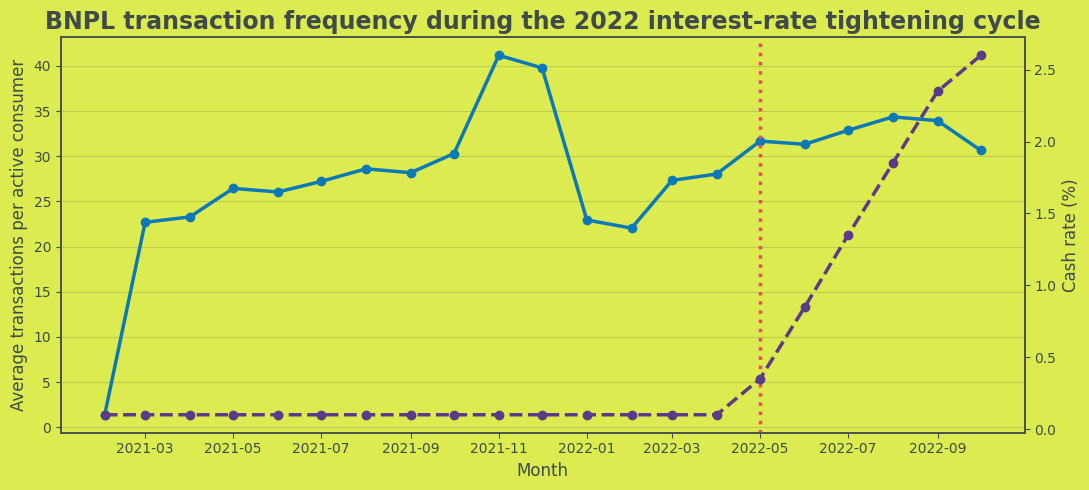

In [7]:
# transaction frequency vs cash rate -- graph 1

SLIDE_BG   = "#DCEB4F"
SLIDE_TEXT = "#3F4A4A"
SLIDE_EDGE = "#4B5552"

BLUE   = "#0B79B7"
PURPLE = "#5A3B88"
PINK   = "#FF3C73"

fig, ax1 = plt.subplots(figsize=(11, 5))

# background
fig.patch.set_facecolor(SLIDE_BG)
ax1.set_facecolor(SLIDE_BG)

# BNPL transaction frequency
ax1.plot(
    monthly_pd["month"],
    monthly_pd["avg_transactions"],
    marker="o",
    color=BLUE,
    linewidth=2.5
)

ax1.set_xlabel("Month", fontsize=12, color=SLIDE_TEXT)
ax1.set_ylabel(
    "Average transactions per active consumer",
    fontsize=12,
    color=SLIDE_TEXT
)

ax1.tick_params(colors=SLIDE_TEXT)

# cash rate on second axis
ax2 = ax1.twinx()

ax2.plot(
    monthly_pd["month"],
    monthly_pd["cash_rate"],
    marker="o",
    linestyle="--",
    color=PURPLE,
    linewidth=2.5
)

ax2.set_ylabel(
    "Cash rate (%)",
    fontsize=12,
    color=SLIDE_TEXT
)

ax2.tick_params(colors=SLIDE_TEXT)

# May 2022 first rate hike
ax1.axvline(
    pd.Timestamp("2022-05-01"),
    linestyle=":",
    linewidth=2.5,
    color=PINK
)

# title
ax1.set_title(
    "BNPL transaction frequency during the 2022 interest-rate tightening cycle",
    fontsize=17,
    fontweight="bold",
    color=SLIDE_TEXT
)

# borders
for ax in [ax1, ax2]:
    for spine in ax.spines.values():
        spine.set_color(SLIDE_EDGE)
        spine.set_linewidth(1.3)

# subtle grid
ax1.grid(
    axis="y",
    alpha=0.20,
    color=SLIDE_EDGE
)

plt.tight_layout()
plt.show()

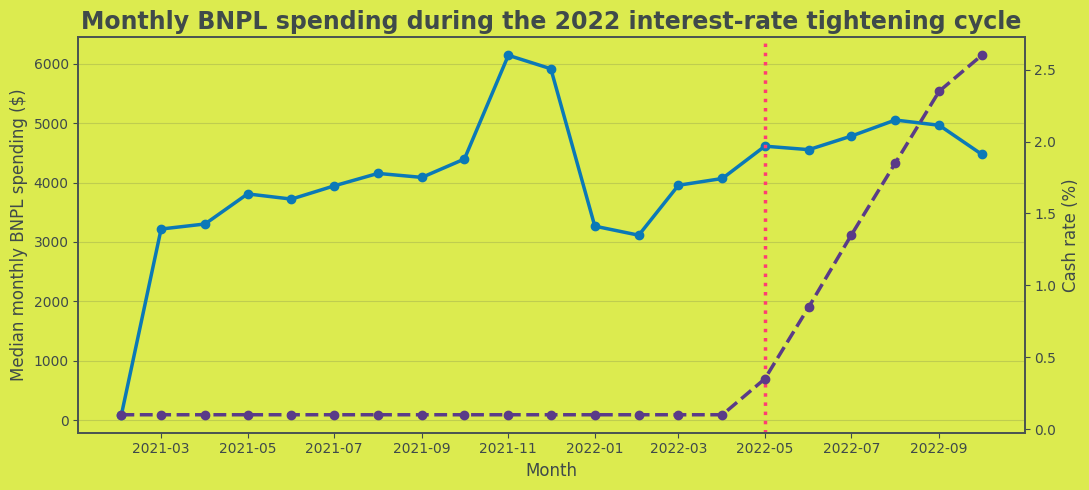

In [8]:
# monthly spending vs cash rate -- graph 2
SLIDE_BG   = "#DCEB4F"
SLIDE_TEXT = "#3F4A4A"
SLIDE_EDGE = "#4B5552"

BLUE   = "#0B79B7"
PURPLE = "#5A3B88"
PINK   = "#FF3C73"

fig, ax1 = plt.subplots(figsize=(11, 5))

# background
fig.patch.set_facecolor(SLIDE_BG)
ax1.set_facecolor(SLIDE_BG)

# median monthly spending
ax1.plot(
    monthly_pd["month"],
    monthly_pd["median_monthly_spend"],
    marker="o",
    color=BLUE,
    linewidth=2.5
)

ax1.set_xlabel("Month", fontsize=12, color=SLIDE_TEXT)
ax1.set_ylabel(
    "Median monthly BNPL spending ($)",
    fontsize=12,
    color=SLIDE_TEXT
)

ax1.tick_params(colors=SLIDE_TEXT)

# cash rate
ax2 = ax1.twinx()

ax2.plot(
    monthly_pd["month"],
    monthly_pd["cash_rate"],
    marker="o",
    linestyle="--",
    color=PURPLE,
    linewidth=2.5
)

ax2.set_ylabel(
    "Cash rate (%)",
    fontsize=12,
    color=SLIDE_TEXT
)

ax2.tick_params(colors=SLIDE_TEXT)

# May 2022 rate-hike marker
ax1.axvline(
    pd.Timestamp("2022-05-01"),
    linestyle=":",
    linewidth=2.5,
    color=PINK
)

# title
ax1.set_title(
    "Monthly BNPL spending during the 2022 interest-rate tightening cycle",
    fontsize=17,
    fontweight="bold",
    color=SLIDE_TEXT
)

# borders
for ax in [ax1, ax2]:
    for spine in ax.spines.values():
        spine.set_color(SLIDE_EDGE)
        spine.set_linewidth(1.3)

# subtle grid
ax1.grid(
    axis="y",
    alpha=0.20,
    color=SLIDE_EDGE
)

plt.tight_layout()
plt.show()

The November 2021 spike likely reflects holidays and events such as Black Friday, early Christmas spending, and post-lockdown demand rather than interest-rate effects. However there is a relationship to be observed in both these graphs.

The descriptive trends show that BNPL activity initially increased alongside the RBA's 2022 rate-hiking cycle, before softening toward October; before the first rate rise (April 2022) when the cash rate was 0.10%, consumers made an average of 28.03 BNPL transactions per month and median monthly BNPL spending was $4,067.46.

By May 2022 after the cash rate increased to 0.35%, average transaction frequency had risen to 31.67 transactions, while median monthly spending increased to $4,611.68.

BNPL activity continued to rise as rates increased. In August 2022, with the cash rate at 1.85%, average transaction frequency reached 34.35 transactions and median monthly spending reached $5,051.21.

Represents an increase of approximately **22.5% in transaction frequency** and **24.2% in median monthly spending** by August. However, as the cash rate increased further to 2.60% in October 2022, activity slowed to 30.63 transactions and $4,474.76 median monthly spending**. These still remained approximately 9.3% and 10.0% above April levels, respectively.

In [9]:
# adding essential products to test against demographics
essential_lookup = (
    spark.read.parquet("../data/curated/merged_transactions_sa2.parquet")
    .select("merchant_abn", "is_essential")
    .dropDuplicates(["merchant_abn"])
)

tx_analysis = (
    tx_full
    .join(
        essential_lookup,
        on="merchant_abn",
        how="left"
    )
)

print("FULL TRANSACTIONS:", tx_analysis.count())

print(
    "MISSING ESSENTIALITY:",
    tx_analysis.filter(F.col("is_essential").isNull()).count()
)

tx_analysis.groupBy("is_essential").count().show()

FULL TRANSACTIONS: 14195717


MISSING ESSENTIALITY: 707904


+-------------+-------+
| is_essential|  count|
+-------------+-------+
|   borderline|2313277|
|         NULL| 707904|
|not_essential|9611840|
|    essential|1562696|
+-------------+-------+



In [10]:
# essential vs non-essnential monthly behaviour
essential_monthly = (
    tx_analysis
    .withColumn(
        "month",
        F.date_trunc("month", F.col("order_datetime"))
    )
    .groupBy("month", "is_essential")
    .agg(
        F.countDistinct("user_id").alias("active_consumers"),
        F.countDistinct("order_id").alias("transactions"),
        F.sum("dollar_value").alias("total_spend")
    )
    .withColumn(
        "transactions_per_consumer",
        F.col("transactions") / F.col("active_consumers")
    )
    .withColumn(
        "spend_per_consumer",
        F.col("total_spend") / F.col("active_consumers")
    )
    .join(rba_monthly, on="month", how="left")
    .orderBy("month", "is_essential")
)

essential_pd = essential_monthly.toPandas()
essential_pd["month"] = pd.to_datetime(essential_pd["month"])

print(
    essential_pd.round({
        "cash_rate": 2,
        "transactions_per_consumer": 2,
        "spend_per_consumer": 2
    }).to_string(index=False)
)

     month  is_essential  active_consumers  transactions  total_spend  transactions_per_consumer  spend_per_consumer  cash_rate
2021-02-01          None               834           851 2.447701e+05                       1.02              293.49       0.10
2021-02-01    borderline              2622          2769 4.311233e+05                       1.06              164.43       0.10
2021-02-01     essential              1876          1941 3.997211e+05                       1.03              213.07       0.10
2021-02-01 not_essential              9110         11546 1.708475e+06                       1.27              187.54       0.10
2021-03-01          None             16425         27381 8.839222e+06                       1.67              538.16       0.10
2021-03-01    borderline             23475         88923 1.470438e+07                       3.79              626.38       0.10
2021-03-01     essential             22151         59905 1.229875e+07                       2.70        

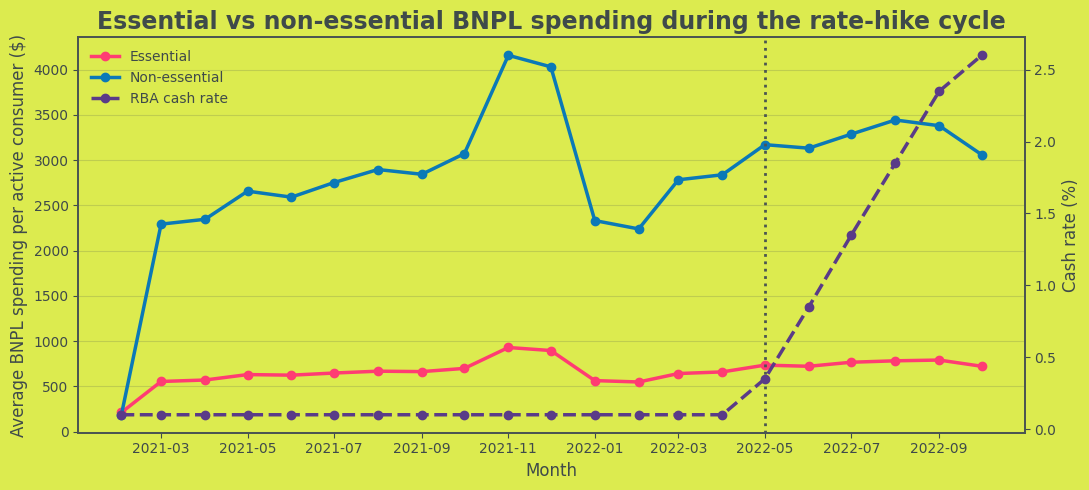

In [14]:
# essential spending vs cash rate -- graph 3
SLIDE_BG   = "#DCEB4F"
SLIDE_TEXT = "#3F4A4A"
SLIDE_EDGE = "#4B5552"

BLUE   = "#0B79B7"
PINK   = "#FF3C73"
PURPLE = "#5A3B88"

fig, ax1 = plt.subplots(figsize=(11, 5))

fig.patch.set_facecolor(SLIDE_BG)
ax1.set_facecolor(SLIDE_BG)

essential = essential_pd[
    essential_pd["is_essential"] == "essential"
]

ax1.plot(
    essential["month"],
    essential["spend_per_consumer"],
    marker="o",
    linewidth=2.5,
    color=PINK,
    label="Essential"
)

nonessential = essential_pd[
    essential_pd["is_essential"] == "not_essential"
]

ax1.plot(
    nonessential["month"],
    nonessential["spend_per_consumer"],
    marker="o",
    linewidth=2.5,
    color=BLUE,
    label="Non-essential"
)

# LEFT AXIS
ax1.set_xlabel(
    "Month",
    fontsize=12,
    color=SLIDE_TEXT
)

ax1.set_ylabel(
    "Average BNPL spending per active consumer ($)",
    fontsize=12,
    color=SLIDE_TEXT
)

ax1.tick_params(colors=SLIDE_TEXT)
ax2 = ax1.twinx()

cash_rate = (
    essential_pd[
        ["month", "cash_rate"]
    ]
    .drop_duplicates()
    .sort_values("month")
)

ax2.plot(
    cash_rate["month"],
    cash_rate["cash_rate"],
    marker="o",
    linestyle="--",
    linewidth=2.5,
    color=PURPLE,
    label="RBA cash rate"
)

ax2.set_ylabel(
    "Cash rate (%)",
    fontsize=12,
    color=SLIDE_TEXT
)

ax2.tick_params(colors=SLIDE_TEXT)
ax1.axvline(
    pd.Timestamp("2022-05-01"),
    linestyle=":",
    linewidth=2,
    color=SLIDE_EDGE
)

# TITLE
ax1.set_title(
    "Essential vs non-essential BNPL spending during the rate-hike cycle",
    fontsize=17,
    fontweight="bold",
    color=SLIDE_TEXT
)

# BORDERS
for ax in [ax1, ax2]:
    for spine in ax.spines.values():
        spine.set_color(SLIDE_EDGE)
        spine.set_linewidth(1.3)

ax1.grid(
    axis="y",
    alpha=0.20,
    color=SLIDE_EDGE
)

# COMBINED LEGEND
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

legend = ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    frameon=False,
    loc="upper left"
)

for text in legend.get_texts():
    text.set_color(SLIDE_TEXT)

plt.tight_layout()
plt.show()

The results suggest that essential and non-essential BNPL spending responded differently in magnitude, but followed broadly similar movements during the 2022 rate-hiking cycle.

Non-essential spending was consistently much higher than essential spending. Around the beginning of the rate-hiking cycle in May 2022, average non-essential BNPL spending was approximately $3,150 per active consumer, compared with roughly $730 for essential purchases. Yet, as the cash rate increased from 0.35% in May 2022 to 1.85% in August 2022, spending in both groups initially increased. Non-essential spending rose from approximately $3,150 to $3,450 per consumer, while essential spending increased from around $730 to approximately $780–$800 (9-10% increase and 7-9% increase respectively).

When the cash rate tightened to 2.60% by October 2022, spending in both categories declined. Non-essential spending fell to approximately $3,050 per consumer, while essential spending declined to approximately $710–$730. The decline was more visible for non-essential purchases, suggesting that discretionary BNPL spending may have been more responsive as monetary-policy tightening became more substantial. Having less money to spend meant that BNPL was not used as much for non-essential purchases while essential purchases remained relatively stable.

A similar seasonal pattern as continously visible. 

In [15]:
# adding demographics to spending
demo_source = spark.read.parquet(
    "../data/curated/final_external_enriched"
)

# one demographic profile per user
demo_lookup = (
    demo_source
    .select(
        "user_id",
        "Median_age_persons",
        "Median_mortgage_repay_monthly",
        "poa_irsd_score",
        "poa_irsad_score"
    )
    .groupBy("user_id")
    .agg(
        F.first("Median_age_persons", ignorenulls=True).alias("Median_age_persons"),
        F.first("Median_mortgage_repay_monthly", ignorenulls=True).alias("Median_mortgage_repay_monthly"),
        F.first("poa_irsd_score", ignorenulls=True).alias("poa_irsd_score"),
        F.first("poa_irsad_score", ignorenulls=True).alias("poa_irsad_score")
    )
)

age_cut = demo_lookup.approxQuantile(
    "Median_age_persons", [0.5], 0.01
)[0]
mortgage_cut = demo_lookup.approxQuantile(
    "Median_mortgage_repay_monthly", [0.5], 0.01
)[0]
irsd_cut = demo_lookup.approxQuantile(
    "poa_irsd_score", [0.5], 0.01
)[0]
irsad_cut = demo_lookup.approxQuantile(
    "poa_irsad_score", [0.5], 0.01
)[0]

print("Median age cut-off:", age_cut)
print("Median mortgage cut-off:", mortgage_cut)
print("Median IRSD cut-off:", irsd_cut)
print("Median IRSAD cut-off:", irsad_cut)

demo_lookup = (
    demo_lookup
    .withColumn(
        "younger_area",
        (F.col("Median_age_persons") <= age_cut).cast("int")
    )
    .withColumn(
        "higher_disadvantage",
        (F.col("poa_irsd_score") <= irsd_cut).cast("int")
    )
    .withColumn(
        "lower_advantage",
        (F.col("poa_irsad_score") <= irsad_cut).cast("int")
    )
    .withColumn(
        "higher_mortgage",
        (F.col("Median_mortgage_repay_monthly") >= mortgage_cut).cast("int")
    )
)

tx_demo = (
    tx_full
    .join(
        demo_lookup,
        on="user_id",
        how="left"
    )
    .withColumn(
        "month",
        F.date_trunc("month", F.col("order_datetime"))
    )
)

print("TRANSACTIONS:", tx_demo.count())

print(
    "MISSING DEMOGRAPHIC PROFILE:",
    tx_demo.filter(
        F.col("Median_age_persons").isNull()
    ).count()
)

Median age cut-off: 43.00000015433247
Median mortgage cut-off: 1499.9999999525555
Median IRSD cut-off: 1000.5161280000001
Median IRSAD cut-off: 977.1344316000001
TRANSACTIONS: 14195717


MISSING DEMOGRAPHIC PROFILE: 4600937


In [16]:
# demographic spending over time
demo_variables = {
    "younger_area": "Younger area",
    "higher_disadvantage": "Higher disadvantage",
    "lower_advantage": "Lower advantage",
    "higher_mortgage": "Higher mortgage repayments"
}

demo_monthly_parts = []
for variable, label in demo_variables.items():

    temp = (
        tx_demo
        .filter(F.col(variable).isNotNull())
        .groupBy("month", variable)
        .agg(
            F.countDistinct("user_id").alias("active_consumers"),
            F.countDistinct("order_id").alias("transactions"),
            F.sum("dollar_value").alias("total_spend")
        )
        .withColumn(
            "spend_per_consumer",
            F.col("total_spend") / F.col("active_consumers")
        )
        .withColumn(
            "transactions_per_consumer",
            F.col("transactions") / F.col("active_consumers")
        )
        .withColumnRenamed(variable, "group")
        .withColumn("demographic", F.lit(label))
    )

    demo_monthly_parts.append(temp)

demo_monthly = demo_monthly_parts[0]

for df in demo_monthly_parts[1:]:
    demo_monthly = demo_monthly.unionByName(df)

demo_monthly = (
    demo_monthly
    .join(
        rba_monthly,
        on="month",
        how="left"
    )
    .orderBy("demographic", "month", "group")
)

demo_pd = demo_monthly.toPandas()
demo_pd["month"] = pd.to_datetime(demo_pd["month"])

print(
    demo_pd[
        [
            "month",
            "demographic",
            "group",
            "active_consumers",
            "spend_per_consumer",
            "transactions_per_consumer",
            "cash_rate"
        ]
    ]
    .round(2)
    .to_string(index=False)
)

     month                demographic  group  active_consumers  spend_per_consumer  transactions_per_consumer  cash_rate
2021-02-01        Higher disadvantage      0              4178              226.86                       1.39       0.10
2021-02-01        Higher disadvantage      1              4064              227.74                       1.40       0.10
2021-03-01        Higher disadvantage      0              8104             3809.13                      22.72       0.10
2021-03-01        Higher disadvantage      1              8051             3744.19                      22.67       0.10
2021-04-01        Higher disadvantage      0              8104             3859.06                      23.32       0.10
2021-04-01        Higher disadvantage      1              8051             3901.20                      23.28       0.10
2021-05-01        Higher disadvantage      0              8104             4388.62                      26.39       0.10
2021-05-01        Higher disadva

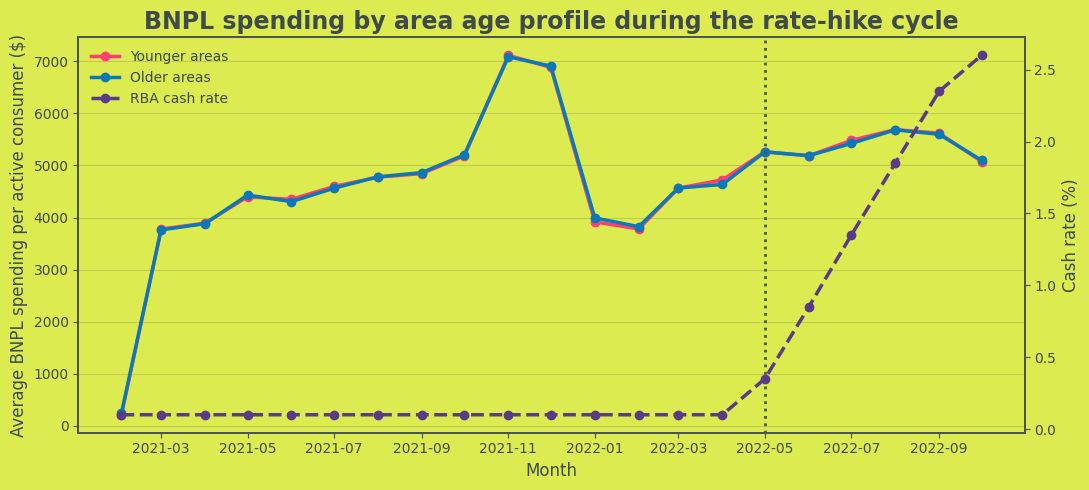

In [17]:
# younger vs older & cash rate -- graph 4
SLIDE_BG   = "#DCEB4F"
SLIDE_TEXT = "#3F4A4A"
SLIDE_EDGE = "#4B5552"

BLUE   = "#0B79B7"
PINK   = "#FF3C73"
PURPLE = "#5A3B88"

plot_df = demo_pd[
    demo_pd["demographic"] == "Younger area"
].copy()

fig, ax1 = plt.subplots(figsize=(11, 5))

fig.patch.set_facecolor(SLIDE_BG)
ax1.set_facecolor(SLIDE_BG)

young = plot_df[plot_df["group"] == 1]
ax1.plot(
    young["month"],
    young["spend_per_consumer"],
    marker="o",
    linewidth=2.5,
    color=PINK,
    label="Younger areas"
)

older = plot_df[plot_df["group"] == 0]
ax1.plot(
    older["month"],
    older["spend_per_consumer"],
    marker="o",
    linewidth=2.5,
    color=BLUE,
    label="Older areas"
)

ax1.set_xlabel("Month", fontsize=12, color=SLIDE_TEXT)

ax1.set_ylabel(
    "Average BNPL spending per active consumer ($)",
    fontsize=12,
    color=SLIDE_TEXT
)

ax2 = ax1.twinx()

cash = (
    plot_df[["month", "cash_rate"]]
    .drop_duplicates()
    .sort_values("month")
)

ax2.plot(
    cash["month"],
    cash["cash_rate"],
    marker="o",
    linestyle="--",
    linewidth=2.5,
    color=PURPLE,
    label="RBA cash rate"
)

ax2.set_ylabel(
    "Cash rate (%)",
    fontsize=12,
    color=SLIDE_TEXT
)

ax1.axvline(
    pd.Timestamp("2022-05-01"),
    linestyle=":",
    linewidth=2,
    color=SLIDE_EDGE
)

ax1.set_title(
    "BNPL spending by area age profile during the rate-hike cycle",
    fontsize=17,
    fontweight="bold",
    color=SLIDE_TEXT
)

for ax in [ax1, ax2]:
    ax.tick_params(colors=SLIDE_TEXT)
    for spine in ax.spines.values():
        spine.set_color(SLIDE_EDGE)
        spine.set_linewidth(1.3)

ax1.grid(axis="y", alpha=0.20, color=SLIDE_EDGE)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

legend = ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    frameon=False,
    loc="upper left"
)

for text in legend.get_texts():
    text.set_color(SLIDE_TEXT)

plt.tight_layout()
plt.show()

The two spending lines remain almost completely overlapping throughout the sample. This indicates that area age profile does not appear to  change spending behaviour in any significant manner when plotted against rising interest rates.

Both groups show the same broader pattern observed in the overall analysis; spending initially increased during the early stages of monetary tightening before moderating as the cash rate moved above 2%.

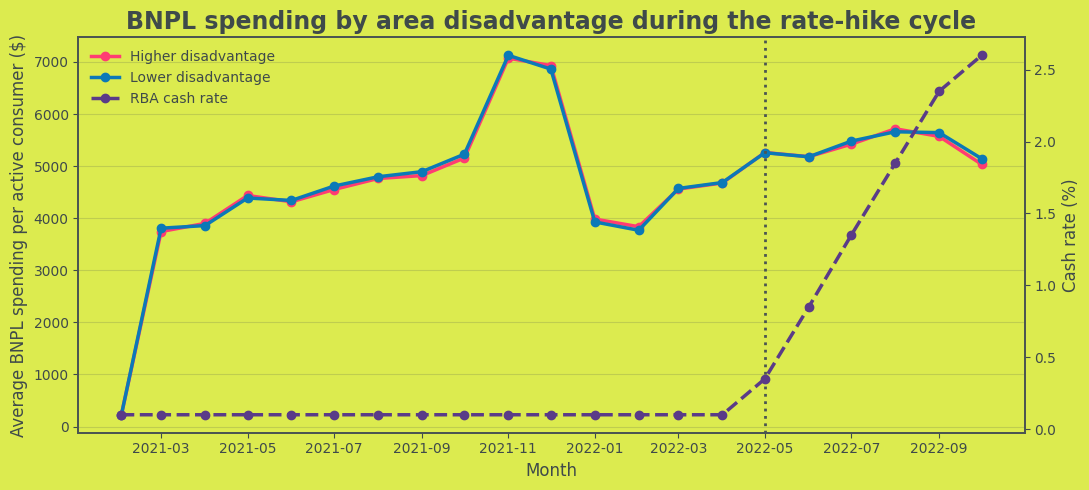

In [18]:
# high vs lower disdvantage & cash rate -- graph 5
SLIDE_BG   = "#DCEB4F"
SLIDE_TEXT = "#3F4A4A"
SLIDE_EDGE = "#4B5552"

BLUE   = "#0B79B7"
PINK   = "#FF3C73"
PURPLE = "#5A3B88"

plot_df = demo_pd[
    demo_pd["demographic"] == "Higher disadvantage"
].copy()

fig, ax1 = plt.subplots(figsize=(11, 5))

fig.patch.set_facecolor(SLIDE_BG)
ax1.set_facecolor(SLIDE_BG)

high_disadv = plot_df[plot_df["group"] == 1]
ax1.plot(
    high_disadv["month"],
    high_disadv["spend_per_consumer"],
    marker="o",
    linewidth=2.5,
    color=PINK,
    label="Higher disadvantage"
)

lower_disadv = plot_df[plot_df["group"] == 0]
ax1.plot(
    lower_disadv["month"],
    lower_disadv["spend_per_consumer"],
    marker="o",
    linewidth=2.5,
    color=BLUE,
    label="Lower disadvantage"
)

ax1.set_xlabel(
    "Month",
    fontsize=12,
    color=SLIDE_TEXT
)
ax1.set_ylabel(
    "Average BNPL spending per active consumer ($)",
    fontsize=12,
    color=SLIDE_TEXT
)

ax2 = ax1.twinx()
cash = (
    plot_df[["month", "cash_rate"]]
    .drop_duplicates()
    .sort_values("month")
)

ax2.plot(
    cash["month"],
    cash["cash_rate"],
    marker="o",
    linestyle="--",
    linewidth=2.5,
    color=PURPLE,
    label="RBA cash rate"
)

ax2.set_ylabel(
    "Cash rate (%)",
    fontsize=12,
    color=SLIDE_TEXT
)

ax1.axvline(
    pd.Timestamp("2022-05-01"),
    linestyle=":",
    linewidth=2,
    color=SLIDE_EDGE
)

ax1.set_title(
    "BNPL spending by area disadvantage during the rate-hike cycle",
    fontsize=17,
    fontweight="bold",
    color=SLIDE_TEXT
)

for ax in [ax1, ax2]:
    ax.tick_params(colors=SLIDE_TEXT)

    for spine in ax.spines.values():
        spine.set_color(SLIDE_EDGE)
        spine.set_linewidth(1.3)

ax1.grid(
    axis="y",
    alpha=0.20,
    color=SLIDE_EDGE
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

legend = ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    frameon=False,
    loc="upper left"
)

for text in legend.get_texts():
    text.set_color(SLIDE_TEXT)

plt.tight_layout()
plt.show()

Once again, both groups continue to almost completely overlap throughout the sample. This indicates that socio-economic advantage also does not appear to change spending behaviour in any significant manner when plotted against rising interest rates.

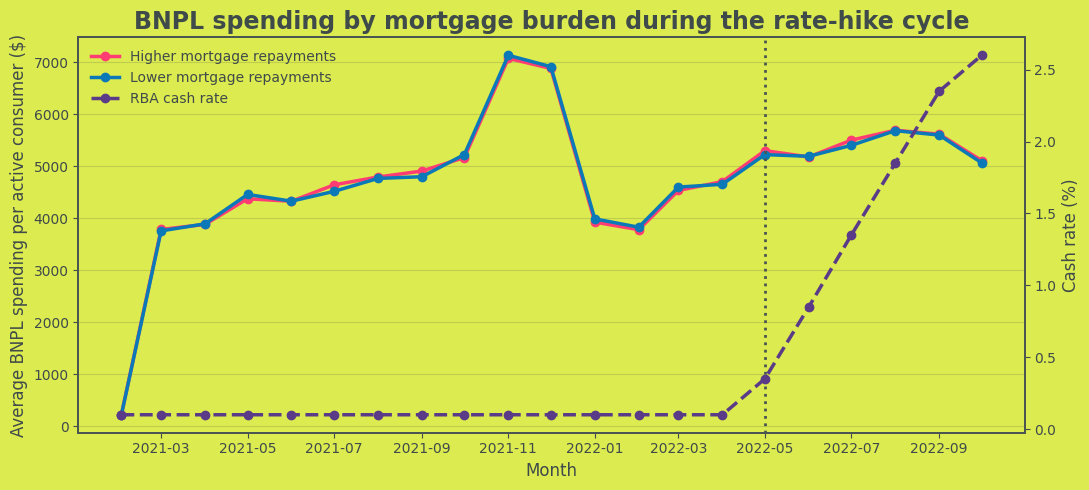

In [19]:
# higher mortgage vs lower mortgage & cash rate
SLIDE_BG   = "#DCEB4F"
SLIDE_TEXT = "#3F4A4A"
SLIDE_EDGE = "#4B5552"

BLUE   = "#0B79B7"
PINK   = "#FF3C73"
PURPLE = "#5A3B88"

plot_df = demo_pd[
    demo_pd["demographic"] == "Higher mortgage repayments"
].copy()

fig, ax1 = plt.subplots(figsize=(11, 5))

fig.patch.set_facecolor(SLIDE_BG)
ax1.set_facecolor(SLIDE_BG)


high_mortgage = plot_df[plot_df["group"] == 1]
ax1.plot(
    high_mortgage["month"],
    high_mortgage["spend_per_consumer"],
    marker="o",
    linewidth=2.5,
    color=PINK,
    label="Higher mortgage repayments"
)

low_mortgage = plot_df[plot_df["group"] == 0]
ax1.plot(
    low_mortgage["month"],
    low_mortgage["spend_per_consumer"],
    marker="o",
    linewidth=2.5,
    color=BLUE,
    label="Lower mortgage repayments"
)

ax1.set_xlabel(
    "Month",
    fontsize=12,
    color=SLIDE_TEXT
)

ax1.set_ylabel(
    "Average BNPL spending per active consumer ($)",
    fontsize=12,
    color=SLIDE_TEXT
)

ax2 = ax1.twinx()
cash = (
    plot_df[["month", "cash_rate"]]
    .drop_duplicates()
    .sort_values("month")
)

ax2.plot(
    cash["month"],
    cash["cash_rate"],
    marker="o",
    linestyle="--",
    linewidth=2.5,
    color=PURPLE,
    label="RBA cash rate"
)

ax2.set_ylabel(
    "Cash rate (%)",
    fontsize=12,
    color=SLIDE_TEXT
)

ax1.axvline(
    pd.Timestamp("2022-05-01"),
    linestyle=":",
    linewidth=2,
    color=SLIDE_EDGE
)

ax1.set_title(
    "BNPL spending by mortgage burden during the rate-hike cycle",
    fontsize=17,
    fontweight="bold",
    color=SLIDE_TEXT
)

for ax in [ax1, ax2]:
    ax.tick_params(colors=SLIDE_TEXT)

    for spine in ax.spines.values():
        spine.set_color(SLIDE_EDGE)
        spine.set_linewidth(1.3)

ax1.grid(
    axis="y",
    alpha=0.20,
    color=SLIDE_EDGE
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

legend = ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    frameon=False,
    loc="upper left"
)

for text in legend.get_texts():
    text.set_color(SLIDE_TEXT)

plt.tight_layout()
plt.show()

At the beginning of the rate-hiking cycle in May 2022, when the cash rate increased to 0.35%, average BNPL spending was approximately $5,200–$5,300 per active consumer in both mortgage groups. Spending continued to increase for both groups as rates rose. By July–August 2022, with the cash rate between 1.35% and 1.85%, average spending was approximately $5,400–$5,700 per consumer for both groups.

By September 2022, when the cash rate reached 2.35%, spending began to decline in both higher- and lower-mortgage areas and in October 2022, with the cash rate at 2.60%, average BNPL spending had fallen to approximately $5,050 per active consumer** in both groups.

Once again, they completely overlapped. This further supports the conclusion from the prior tests which showed that demographics rarely impacted the rankings. However, it is important to note that these demographics are not for individual customers but postcode areas and therfore may not fully capture the effects of spending. There is no way to give a meaningful recommendation for merchants looking to advertise to certain demogrpahics through the results of this project, but more detailed demographic information could vitalise this experiment for the future. 

In [20]:
# essential product expenditure by postcode 
postcode_summary = (
    tx_analysis
    .filter(F.col("postcode").isNotNull())
    .groupBy("postcode")
    .agg(
        # all distinct BNPL orders
        F.countDistinct("order_id").alias("total_transactions"),

        # clearly classified orders only
        F.countDistinct(
            F.when(
                F.col("is_essential") == "essential",
                F.col("order_id")
            )
        ).alias("essential_transactions"),

        F.countDistinct(
            F.when(
                F.col("is_essential") == "not_essential",
                F.col("order_id")
            )
        ).alias("nonessential_transactions"),

        F.countDistinct("user_id").alias("active_consumers")
    )
    .withColumn(
        "classified_transactions",
        F.col("essential_transactions")
        + F.col("nonessential_transactions")
    )
    .withColumn(
        "essential_share",
        F.when(
            F.col("classified_transactions") > 0,
            F.col("essential_transactions")
            / F.col("classified_transactions")
        )
    )
    .withColumn(
        "transactions_per_consumer",
        F.col("total_transactions")
        / F.col("active_consumers")
    )
)

postcode_pd = postcode_summary.toPandas()

print("POSTCODES:", len(postcode_pd))

print(
    postcode_pd[
        [
            "postcode",
            "total_transactions",
            "essential_transactions",
            "essential_share",
            "active_consumers",
            "transactions_per_consumer"
        ]
    ]
    .sort_values("total_transactions", ascending=False)
    .head(20)
    .round(3)
    .to_string(index=False)
)

POSTCODES: 3161
 postcode  total_transactions  essential_transactions  essential_share  active_consumers  transactions_per_consumer
     7320                  94                      13            0.173                19                      4.947
     3415                  77                       8            0.129                16                      4.812
     4856                  72                      11            0.208                15                      4.800
     4215                  72                       6            0.105                17                      4.235
     5575                  70                      13            0.236                12                      5.833
     3321                  69                       9            0.170                12                      5.750
     3724                  69                       9            0.158                14                      4.929
     7258                  68                      12   

In [21]:
# essential vs transaction relationship
postcode_test = postcode_pd[
    (postcode_pd["classified_transactions"] >= 30) &
    (postcode_pd["active_consumers"] >= 10) &
    postcode_pd["essential_share"].notna()
].copy()

corr = postcode_test[
    ["essential_share", "transactions_per_consumer"]
].corr().iloc[0, 1]

print("Postcodes included:", len(postcode_test))
print(
    "Correlation between essential share and "
    f"transactions per consumer: {corr:.3f}"
)

Postcodes included: 224
Correlation between essential share and transactions per consumer: -0.057


Matched postcodes: 2553


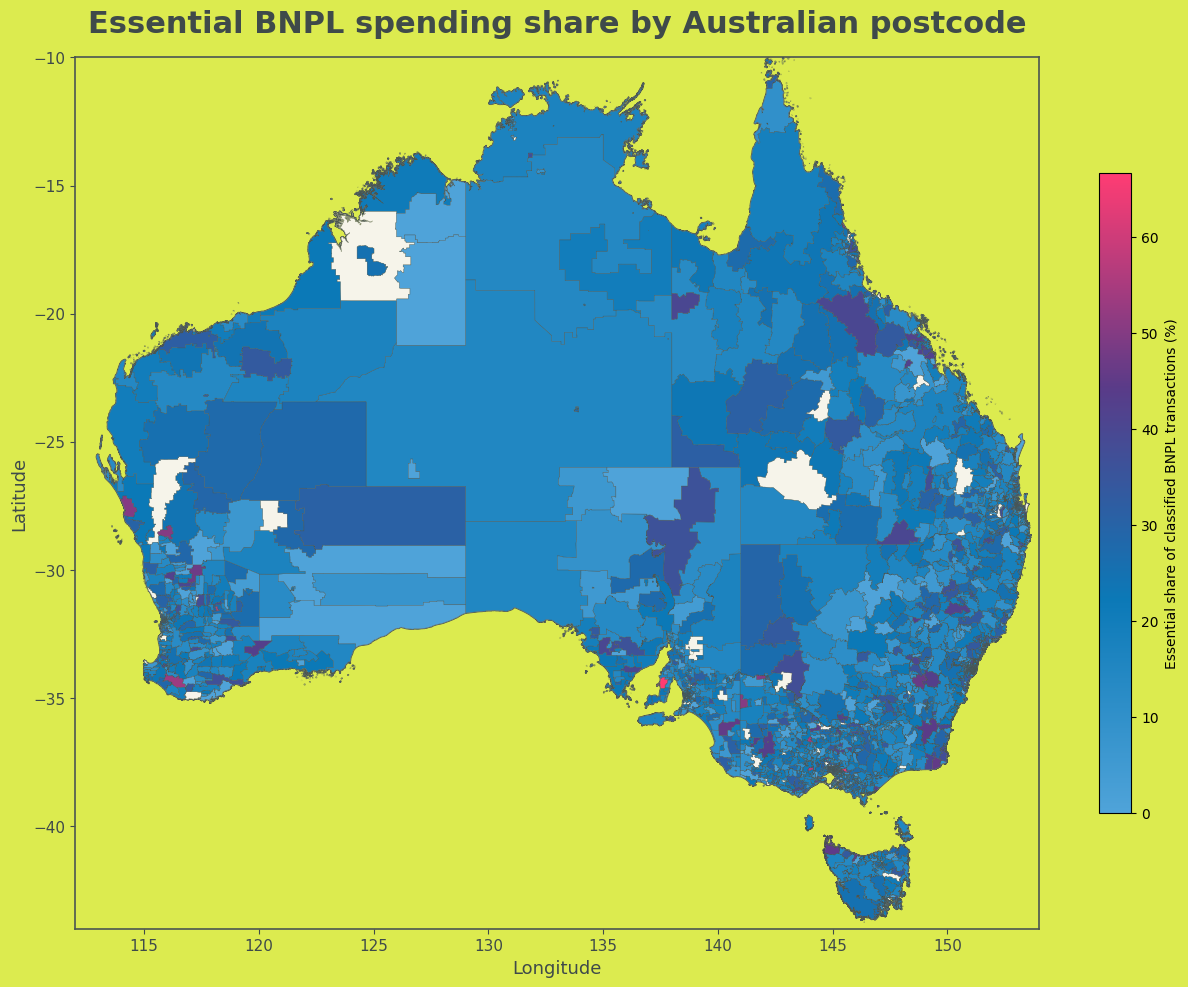

In [26]:
# essential spending geospatial map -- graph 6
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import os

folder = "../data/curated/abs_poa_2021"

shp_file = [
    os.path.join(folder, f)
    for f in os.listdir(folder)
    if f.endswith(".shp")
][0]

poa_map = gpd.read_file(shp_file)

map_data = postcode_pd[
    (postcode_pd["classified_transactions"] >= 5) &
    postcode_pd["essential_share"].notna()
].copy()

map_data["postcode"] = (
    map_data["postcode"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.zfill(4)
)

map_data["essential_share_pct"] = map_data["essential_share"] * 100
poa_map["POA_CODE21"] = poa_map["POA_CODE21"].astype(str)

map_gdf = poa_map.merge(
    map_data,
    left_on="POA_CODE21",
    right_on="postcode",
    how="left"
)

print("Matched postcodes:", map_gdf["essential_share_pct"].notna().sum())

SLIDE_BG   = "#DCEB4F"   # your slide background
SLIDE_TEXT = "#3F4A4A"
COUNTRY_FILL = "#F6F4EA" # light neutral so Australia is visible
COUNTRY_EDGE = "#8E9670" # soft boundary lines
OUTLINE_EDGE = "#4B5552" # darker country outline

cmap = mcolors.LinearSegmentedColormap.from_list(
    "essential_share_map",
    [
        "#4FA3D9",   # low
        "#0B79B7",
        "#5A3B88",
        "#FF3C73"    # high
    ]
)

aust_outline = poa_map.dissolve()

fig, ax = plt.subplots(figsize=(13, 10))
fig.patch.set_facecolor(SLIDE_BG)
ax.set_facecolor(SLIDE_BG)

aust_outline.plot(
    ax=ax,
    facecolor=COUNTRY_FILL,
    edgecolor=OUTLINE_EDGE,
    linewidth=1.2,
    zorder=1
)

poa_map.plot(
    ax=ax,
    facecolor=COUNTRY_FILL,
    edgecolor=COUNTRY_EDGE,
    linewidth=0.15,
    alpha=1.0,
    zorder=2
)

map_gdf[map_gdf["essential_share_pct"].notna()].plot(
    ax=ax,
    column="essential_share_pct",
    cmap=cmap,
    edgecolor=OUTLINE_EDGE,
    linewidth=0.25,
    legend=True,
    zorder=3,
    legend_kwds={
        "label": "Essential share of classified BNPL transactions (%)",
        "shrink": 0.7
    }
)

ax.set_title(
    "Essential BNPL spending share by Australian postcode",
    fontsize=22,
    fontweight="bold",
    color=SLIDE_TEXT,
    pad=18
)

ax.set_xlabel("Longitude", fontsize=13, color=SLIDE_TEXT)
ax.set_ylabel("Latitude", fontsize=13, color=SLIDE_TEXT)

ax.tick_params(axis="both", colors=SLIDE_TEXT, labelsize=11)

for spine in ax.spines.values():
    spine.set_color(OUTLINE_EDGE)
    spine.set_linewidth(1.2)

ax.set_xlim(112, 154)
ax.set_ylim(-44, -10)

plt.tight_layout()
plt.show()

Original postcodes: 3161
Postcodes going into frequency map: 3012
Matched postcodes on map: 2512
Colour scale: 2.5 to 5.75


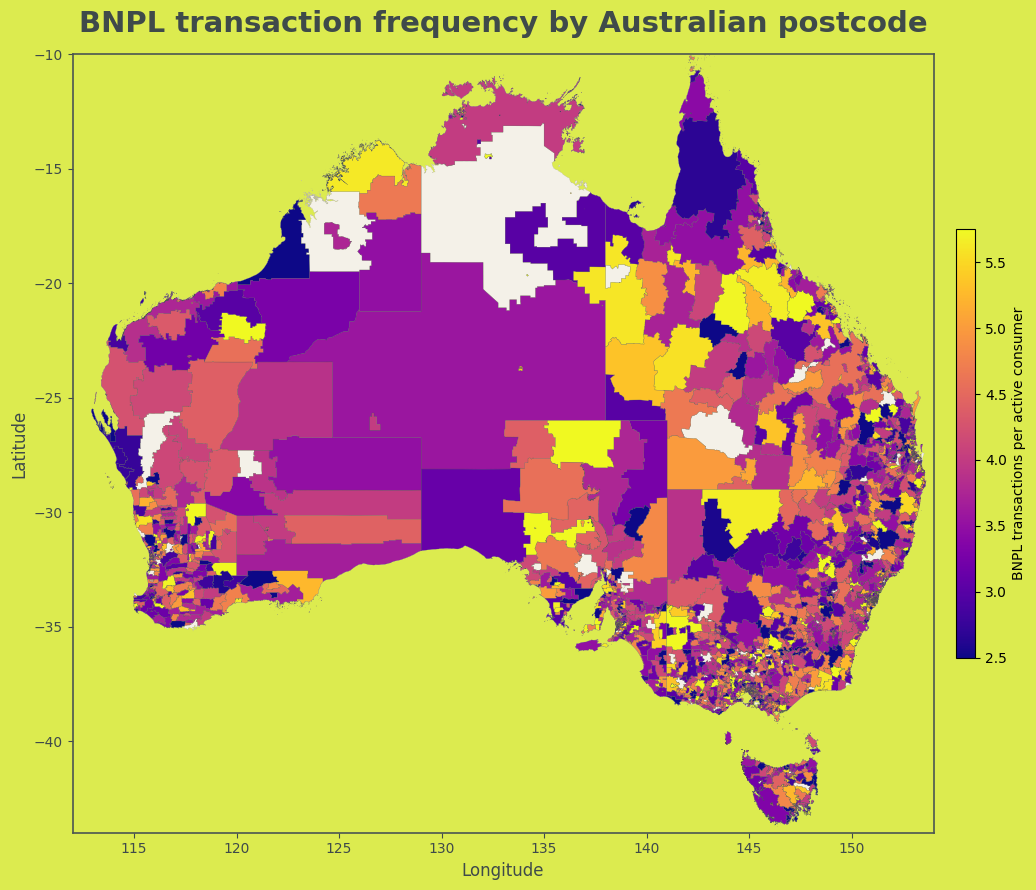

In [29]:
# transaction frequency geospatial map -- graph 7
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

SLIDE_BG   = "#DCEB4F"
SLIDE_TEXT = "#3F4A4A"
SLIDE_EDGE = "#4B5552"

MAP_BASE = "#F4F1E8"

freq_map = postcode_pd[
    (postcode_pd["active_consumers"] >= 3) &
    (postcode_pd["total_transactions"] >= 5) &
    postcode_pd["transactions_per_consumer"].notna()
].copy()

freq_map["postcode"] = (
    freq_map["postcode"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.zfill(4)
)

print("Original postcodes:", len(postcode_pd))
print("Postcodes going into frequency map:", len(freq_map))

poa = poa_map.copy()

poa["postcode"] = (
    poa["POA_CODE21"]
    .astype(str)
    .str.zfill(4)
)

freq_geo = poa.merge(
    freq_map,
    on="postcode",
    how="left"
)

print(
    "Matched postcodes on map:",
    freq_geo["transactions_per_consumer"].notna().sum()
)

values = freq_map["transactions_per_consumer"]

vmin = values.quantile(0.05)
vmax = values.quantile(0.95)

print("Colour scale:", round(vmin, 2), "to", round(vmax, 2))

fig, ax = plt.subplots(figsize=(12, 9))

fig.patch.set_facecolor(SLIDE_BG)
ax.set_facecolor(SLIDE_BG)

poa.plot(
    ax=ax,
    facecolor=MAP_BASE,
    edgecolor="#B5B3A8",
    linewidth=0.15,
    zorder=1
)

freq_geo[
    freq_geo["transactions_per_consumer"].notna()
].plot(
    ax=ax,
    column="transactions_per_consumer",
    cmap="plasma",
    vmin=vmin,
    vmax=vmax,
    edgecolor=SLIDE_EDGE,
    linewidth=0.15,
    legend=True,
    zorder=2,
    legend_kwds={
        "label": "BNPL transactions per active consumer",
        "shrink": 0.55,
        "aspect": 22,
        "pad": 0.02
    }
)

ax.set_xlim(112, 154)
ax.set_ylim(-44, -10)

ax.set_title(
    "BNPL transaction frequency by Australian postcode",
    fontsize=21,
    fontweight="bold",
    color=SLIDE_TEXT,
    pad=16
)

ax.set_xlabel(
    "Longitude",
    fontsize=12,
    color=SLIDE_TEXT
)

ax.set_ylabel(
    "Latitude",
    fontsize=12,
    color=SLIDE_TEXT
)

ax.tick_params(colors=SLIDE_TEXT)

for spine in ax.spines.values():
    spine.set_color(SLIDE_EDGE)
    spine.set_linewidth(1.2)

plt.tight_layout()
plt.show()

The postcode maps reveal a clear spatial contrast between areas with a high share of essential BNPL purchases and areas with high overall BNPL transaction frequency.

Postcodes with a higher proportion of essential BNPL transactions generally appear to have lower transaction frequency per active consumer. In contrast, many areas with relatively low essential-spending shares display higher overall BNPL transaction intensity. This suggests that consumers in high-essential-share areas may use BNPL more selectively for necessary purchases, rather than making a large number of transactions across different product categories. This is useful for various merchants, such as those selling essential products as high-essential-share postcodes may represent valuable target markets even when overall transaction frequency is comparatively low. Marketing in these areas could focus on necessity, affordability, payment flexibility, and practical value as opposed to encouraging high purchase frequency.

The opposite pattern may be more relevant for luxury and other high-spenditure merchants. Postcodes showing high transaction frequency but relatively low essential-spending shares potentially represent consumers with greater engagement in discretionary BNPL purchasing. These areas could therefore be stronger candidates for campaigns centred on fashion, technology, leisure, luxury, and other non-essential products.

Importantly, a postcode with fewer transactions is not necessarily commercially unattractive; some locations appear more essential-oriented, others appear more frequent and discretionary.